# 020 - Gerar relatório de dados por UF

## Objetivo
Gerar o relatório estadual de dados para uma Unidade da Federação por execução. Este notebook consome apenas os CSVs produzidos pelo `010_extracao_transformacao.ipynb`.

## Quando executar
Execute este notebook quando quiser gerar ou revisar o relatório Word de uma UF específica.

## Entradas principais
- `dados_intermediarios/<AAAAMM>/consolidado/indicadores_brasil_uf.csv`.
- `dados_intermediarios/<AAAAMM>/consolidado/series_historicas_pronaf_ater_uf.csv`.
- `templates/imagens/institucional/cabecalho_mda_brasil.png`.

## Saídas principais
- `relatorios_gerados/<AAAAMM>/tabelas/<UF>/`: tabelas em CSV usadas no relatório.
- `relatorios_gerados/<AAAAMM>/graficos/<UF>/`: gráficos PNG usados no Word.
- `relatorios_gerados/<AAAAMM>/relatorio_dados_<UF>_<timestamp>.docx`.

## Fluxo de trabalho
1. ler bases consolidadas em CSV;
2. filtrar uma UF;
3. tratar cada política em seção própria;
4. imprimir e salvar tabelas;
5. gerar, imprimir e salvar gráficos PNG;
6. montar o Word apenas depois que todos os insumos estiverem prontos.

## Parâmetros importantes
- `UF_INTERESSE`: UF do relatório. Pode ser definida no notebook ou por variável de ambiente.
- `ANO_MES_INTERMEDIARIO`: competência da pasta de dados intermediários. Quando `None`, usa a pasta mais recente.

Para geração em lote, use o notebook `030_gerar_relatorios_todas_ufs.ipynb`.

## 1. Importar bibliotecas

As bibliotecas abaixo cobrem leitura dos CSVs, geracao dos graficos, criacao do Word e organizacao de caminhos.

In [69]:
from datetime import datetime
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_CELL_VERTICAL_ALIGNMENT
    from docx.oxml import OxmlElement
    from docx.oxml.ns import qn
except ImportError:
    # Mantem o notebook executavel em ambientes novos, como Colab recem-iniciado.
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-docx"])
    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_CELL_VERTICAL_ALIGNMENT
    from docx.oxml import OxmlElement
    from docx.oxml.ns import qn

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Estilo visual simples e consistente para todos os graficos.
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Configurar parâmetros

Altere `UF_INTERESSE` para gerar o relatório de outra UF. O notebook também aceita `UF_INTERESSE` por variável de ambiente, recurso usado pelo notebook `030` para executar várias UFs sem editar este arquivo.

O notebook procura automaticamente a pasta mais recente dentro de `dados_intermediarios` quando `ANO_MES_INTERMEDIARIO` fica como `None`.

In [70]:
# O notebook continua linear e gera um relatório por execução.
# Para execução em lote, o notebook 030 passa estes parâmetros por variável de ambiente.
UF_INTERESSE = os.environ.get("UF_INTERESSE", "SC").strip().upper()
ANO_MES_INTERMEDIARIO = os.environ.get("ANO_MES_INTERMEDIARIO") or None
TEXTO_RODAPE = "Contribuições e Dúvidas: damei@mda.gov.br"
PLACEHOLDER_TOTAL_PAGINAS = "[[TOTAL_PAGINAS]]"
ARQUIVO_IMAGEM_CABECALHO = "cabecalho_mda_brasil.png"
LARGURA_IMAGEM_CABECALHO_POLEGADAS = 2.55

RUN_TIMESTAMP = datetime.now()
RUN_YYYYMM = RUN_TIMESTAMP.strftime("%Y%m")
RUN_DATETIME = RUN_TIMESTAMP.strftime("%Y%m%d%H%M%S")

CSV_SEP = ";"
CSV_ENCODING = "utf-8-sig"

MODO_DADOS = "google_drive" if "COLAB_RELEASE_TAG" in os.environ else "local"
print(f"Modo de execucao: {MODO_DADOS}")
print(f"UF de interesse: {UF_INTERESSE}")

Modo de execucao: local
UF de interesse: SC


## 3. Resolver caminhos

A estrutura de saída separa tabelas e gráficos por UF. Isso evita sobrescrever arquivos quando diferentes estados forem gerados em sequência.

Estrutura principal usada pelo notebook:

```text
relatorios_gerados/
  <AAAAMM>/
    tabelas/<UF>/
    graficos/<UF>/
    relatorio_dados_<UF>_<timestamp>.docx
```

In [71]:
inicio = Path.cwd().resolve()
PROJECT_ROOT = inicio

# Procura a raiz do repositorio a partir da pasta atual.
for candidato in [inicio, *inicio.parents]:
    if (candidato / "notebooks").exists() and ((candidato / "requirements.txt").exists() or (candidato / "config" / "ufs.csv").exists()):
        PROJECT_ROOT = candidato
        break

if MODO_DADOS == "google_drive":
    from google.colab import drive
    drive.mount("/content/drive")

INTERMEDIARIOS_ROOT = PROJECT_ROOT / "dados_intermediarios"
if ANO_MES_INTERMEDIARIO is None:
    candidatos = sorted([p for p in INTERMEDIARIOS_ROOT.iterdir() if p.is_dir()]) if INTERMEDIARIOS_ROOT.exists() else []
    if not candidatos:
        raise FileNotFoundError(f"Nenhuma pasta encontrada em {INTERMEDIARIOS_ROOT}. Execute primeiro o notebook 010.")
    INPUT_DIR = candidatos[-1]
else:
    INPUT_DIR = INTERMEDIARIOS_ROOT / ANO_MES_INTERMEDIARIO

CONSOLIDADO_DIR = INPUT_DIR / "consolidado"
OUTPUT_DIR = PROJECT_ROOT / "relatorios_gerados" / INPUT_DIR.name
TABELAS_DIR = OUTPUT_DIR / "tabelas" / UF_INTERESSE.upper()
GRAFICOS_DIR = OUTPUT_DIR / "graficos" / UF_INTERESSE.upper()
IMAGENS_TEMPLATE_DIR = PROJECT_ROOT / "templates" / "imagens"
IMAGENS_INSTITUCIONAIS_DIR = IMAGENS_TEMPLATE_DIR / "institucional"
IMAGENS_POLITICAS_DIR = IMAGENS_TEMPLATE_DIR / "politicas"
CAMINHO_IMAGEM_CABECALHO = IMAGENS_INSTITUCIONAIS_DIR / ARQUIVO_IMAGEM_CABECALHO

# A pasta de imagens guarda ativos reutilizaveis do relatorio.
# - institucional: assinatura do cabecalho e marcas gerais do documento.
# - politicas: logos futuras de CAF, PRONAF, ATER, Mais Alimentos e outras politicas.
for pasta in [OUTPUT_DIR, TABELAS_DIR, GRAFICOS_DIR, IMAGENS_TEMPLATE_DIR, IMAGENS_INSTITUCIONAIS_DIR, IMAGENS_POLITICAS_DIR]:
    pasta.mkdir(parents=True, exist_ok=True)

print(f"Raiz do projeto: {PROJECT_ROOT}")
print(f"Entrada intermediaria: {INPUT_DIR}")
print(f"Tabelas: {TABELAS_DIR}")
print(f"Graficos: {GRAFICOS_DIR}")

Raiz do projeto: C:\Users\berna\Documents\mda\automatizacao relatorio
Entrada intermediaria: C:\Users\berna\Documents\mda\automatizacao relatorio\dados_intermediarios\202605
Tabelas: C:\Users\berna\Documents\mda\automatizacao relatorio\relatorios_gerados\202605\tabelas\SC
Graficos: C:\Users\berna\Documents\mda\automatizacao relatorio\relatorios_gerados\202605\graficos\SC


## 4. Ler bases consolidadas

O relatório usa apenas os CSVs consolidados da ETL. Ele não volta aos arquivos Excel brutos; essa separação evita retrabalho e mantém a geração do Word mais estável.

In [72]:
indicadores_path = CONSOLIDADO_DIR / "indicadores_brasil_uf.csv"
series_path = CONSOLIDADO_DIR / "series_historicas_pronaf_ater_uf.csv"

if not indicadores_path.exists():
    raise FileNotFoundError(f"Arquivo nao encontrado: {indicadores_path}")
if not series_path.exists():
    raise FileNotFoundError(f"Arquivo nao encontrado: {series_path}")

df_indicadores = pd.read_csv(indicadores_path, sep=CSV_SEP, encoding=CSV_ENCODING)
df_series = pd.read_csv(series_path, sep=CSV_SEP, encoding=CSV_ENCODING)

# Padroniza campos textuais usados nos filtros.
df_indicadores["uf"] = df_indicadores["uf"].astype(str).str.strip().str.upper()
df_indicadores["politica"] = df_indicadores["politica"].astype(str).str.strip()
df_indicadores["indicador"] = df_indicadores["indicador"].astype(str).str.strip()
df_series["uf"] = df_series["uf"].astype(str).str.strip().str.upper()
df_series["politica"] = df_series["politica"].astype(str).str.strip()
df_series["indicador"] = df_series["indicador"].astype(str).str.strip()
df_series["ano"] = pd.to_numeric(df_series["ano"], errors="coerce").astype("Int64")

if "ranking_brasil" not in df_indicadores.columns:
    raise ValueError("A coluna ranking_brasil nao foi encontrada em indicadores_brasil_uf.csv. Execute primeiro o notebook 010_extracao_transformacao.ipynb atualizado.")

df_indicadores["valor_uf"] = pd.to_numeric(df_indicadores["valor_uf"], errors="coerce")
df_indicadores["valor_brasil"] = pd.to_numeric(df_indicadores["valor_brasil"], errors="coerce").fillna(0)
df_indicadores["percentual_uf_brasil"] = pd.to_numeric(df_indicadores["percentual_uf_brasil"], errors="coerce")
df_indicadores["ranking_brasil"] = df_indicadores["ranking_brasil"].fillna("Sem Informação").astype(str).str.strip()
df_series["valor"] = pd.to_numeric(df_series["valor"], errors="coerce").fillna(0)

historico_dir = INPUT_DIR / "historico"
mais_hist_uf_path = historico_dir / "mais_alimentos_historico_uf.csv"
mais_hist_br_path = historico_dir / "mais_alimentos_historico_brasil.csv"
mais_anual_uf_path = historico_dir / "mais_alimentos_anual_uf.csv"
mais_anual_br_path = historico_dir / "mais_alimentos_anual_brasil.csv"

if mais_hist_uf_path.exists():
    df_mais_hist_uf = pd.read_csv(mais_hist_uf_path, sep=CSV_SEP, encoding=CSV_ENCODING)
    df_mais_hist_uf["uf"] = df_mais_hist_uf["uf"].astype(str).str.strip().str.upper()
    df_mais_hist_uf["competencia"] = df_mais_hist_uf["competencia"].astype(str).str.strip()
    for col in ["qtd_contratos", "valor_total_contratos", "delta_qtd_contratos", "delta_valor_total_contratos"]:
        if col in df_mais_hist_uf.columns:
            df_mais_hist_uf[col] = pd.to_numeric(df_mais_hist_uf[col], errors="coerce").fillna(0)
else:
    df_mais_hist_uf = pd.DataFrame()

if mais_hist_br_path.exists():
    df_mais_hist_brasil = pd.read_csv(mais_hist_br_path, sep=CSV_SEP, encoding=CSV_ENCODING)
    df_mais_hist_brasil["competencia"] = df_mais_hist_brasil["competencia"].astype(str).str.strip()
    for col in ["qtd_contratos", "valor_total_contratos", "delta_qtd_contratos", "delta_valor_total_contratos"]:
        if col in df_mais_hist_brasil.columns:
            df_mais_hist_brasil[col] = pd.to_numeric(df_mais_hist_brasil[col], errors="coerce").fillna(0)
else:
    df_mais_hist_brasil = pd.DataFrame()

# Os valores qtd_contratos / valor_total_contratos sao acumulados YTD
# (year-to-date) dentro do ano-calendario, conforme tratado no notebook 010.
# A serie mensal e exibida apenas para o ano corrente (ANO_INICIO_HISTORICO_MENSAL,
# default: 2026): nao faz sentido sobrepor multiplos ciclos YTD (cada ano reseta
# em janeiro), e a serie historica de longo prazo ja e coberta pela tabela e
# pelos graficos anuais (2013-2025). Os deltas (delta_*) ja vem corretamente
# calculados por (uf, ano) no CSV gerado pelo 010; aqui apenas filtramos as
# competencias.
ANO_INICIO_HISTORICO_MENSAL = 2026
_ano_corte = f"{ANO_INICIO_HISTORICO_MENSAL:04d}"
if not df_mais_hist_uf.empty:
    df_mais_hist_uf = df_mais_hist_uf[df_mais_hist_uf["competencia"].str[:4] >= _ano_corte].copy()
    df_mais_hist_uf = df_mais_hist_uf.sort_values(["uf", "competencia"]).reset_index(drop=True)
if not df_mais_hist_brasil.empty:
    df_mais_hist_brasil = df_mais_hist_brasil[df_mais_hist_brasil["competencia"].str[:4] >= _ano_corte].copy()
    df_mais_hist_brasil = df_mais_hist_brasil.sort_values("competencia").reset_index(drop=True)

if mais_anual_uf_path.exists():
    df_mais_anual_uf = pd.read_csv(mais_anual_uf_path, sep=CSV_SEP, encoding=CSV_ENCODING)
    df_mais_anual_uf["uf"] = df_mais_anual_uf["uf"].astype(str).str.strip().str.upper()
    df_mais_anual_uf["ano"] = pd.to_numeric(df_mais_anual_uf["ano"], errors="coerce").astype("Int64")
    for col in ["qtd_contratos", "valor_total_contratos", "delta_qtd_contratos", "delta_valor_total_contratos"]:
        if col in df_mais_anual_uf.columns:
            df_mais_anual_uf[col] = pd.to_numeric(df_mais_anual_uf[col], errors="coerce").fillna(0)
else:
    df_mais_anual_uf = pd.DataFrame()

if mais_anual_br_path.exists():
    df_mais_anual_brasil = pd.read_csv(mais_anual_br_path, sep=CSV_SEP, encoding=CSV_ENCODING)
    df_mais_anual_brasil["ano"] = pd.to_numeric(df_mais_anual_brasil["ano"], errors="coerce").astype("Int64")
    for col in ["qtd_contratos", "valor_total_contratos", "delta_qtd_contratos", "delta_valor_total_contratos"]:
        if col in df_mais_anual_brasil.columns:
            df_mais_anual_brasil[col] = pd.to_numeric(df_mais_anual_brasil[col], errors="coerce").fillna(0)
else:
    df_mais_anual_brasil = pd.DataFrame()

display(df_indicadores.head())
display(df_series.head())

,politica,indicador,uf,codigo_ibge,nome_uf,valor_uf,valor_brasil,percentual_uf_brasil,ranking_brasil,formato,dt_referencia,dt_geracao,arquivo_origem
0,CAF,UFPA,AC,12,Acre,33319.0,3898268.0,0.854713,22,inteiro,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...
1,CAF,UFPA,AL,27,Alagoas,91048.0,3898268.0,2.335601,12,inteiro,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...
2,CAF,UFPA,AP,16,Amapá,21471.0,3898268.0,0.550783,24,inteiro,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...
3,CAF,UFPA,AM,13,Amazonas,65014.0,3898268.0,1.667766,15,inteiro,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...
4,CAF,UFPA,BA,29,Bahia,720630.0,3898268.0,18.485902,1,inteiro,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...


,politica,ano,uf,codigo_ibge,nome_uf,indicador,valor,formato,dt_referencia,dt_geracao,arquivo_origem
0,PRONAF,2015,AC,12,Acre,Contratos,5.501000e+03,inteiro,2015_12,2026_04_29,pronaf_gaia_historico_anual_2015.xlsx
1,PRONAF,2015,AC,12,Acre,Valor total dos contratos,1.110044e+08,moeda,2015_12,2026_04_29,pronaf_gaia_historico_anual_2015.xlsx
2,PRONAF,2015,AC,12,Acre,Operacoes,5.501000e+03,inteiro,2015_12,2026_04_29,pronaf_gaia_historico_anual_2015.xlsx
3,PRONAF,2015,AL,27,Alagoas,Contratos,5.034000e+04,inteiro,2015_12,2026_04_29,pronaf_gaia_historico_anual_2015.xlsx
4,PRONAF,2015,AL,27,Alagoas,Valor total dos contratos,1.977084e+08,moeda,2015_12,2026_04_29,pronaf_gaia_historico_anual_2015.xlsx


## 5. Filtrar UF e preparar dados auxiliares

A base de indicadores ja traz `valor_brasil`, mas a base historica e agregada novamente para gerar as linhas do Brasil por ano.

In [73]:
UF_INTERESSE = UF_INTERESSE.strip().upper()

if UF_INTERESSE not in set(df_indicadores["uf"]):
    raise ValueError(f"UF {UF_INTERESSE} nao encontrada em indicadores_brasil_uf.csv")

nome_uf = df_indicadores.loc[df_indicadores["uf"] == UF_INTERESSE, "nome_uf"].dropna().iloc[0]
df_indicadores_uf = df_indicadores[df_indicadores["uf"] == UF_INTERESSE].copy()
df_series_uf = df_series[df_series["uf"] == UF_INTERESSE].copy()

# Brasil historico: soma dos valores das 27 UFs para cada politica, ano e indicador.
df_series_brasil = (
    df_series
    .groupby(["politica", "ano", "indicador", "formato"], as_index=False)
    .agg(valor_brasil=("valor", "sum"))
)

print(f"UF selecionada: {UF_INTERESSE} - {nome_uf}")
print(f"Indicadores da UF: {df_indicadores_uf.shape[0]}")
print(f"Linhas historicas da UF: {df_series_uf.shape[0]}")

UF selecionada: SC - Santa Catarina
Indicadores da UF: 25
Linhas historicas da UF: 51


## 6. Sum\u00e1rio Executivo

Esta se\u00e7\u00e3o cria duas tabelas:

1. indicadores atuais principais por pol\u00edtica, comparando UF, Brasil e ranking da UF no m\u00eas de refer\u00eancia;
2. dados hist\u00f3ricos, quando dispon\u00edveis, somando os per\u00edodos `2019 a 2022` e `2023 a 2026`.

As duas tabelas s\u00e3o impressas no notebook e salvas em CSV para posterior inclus\u00e3o no Word.

In [74]:
# Tabela 1: indicadores atuais principais para leitura rapida da alta gestao.
indicadores_chave = [
    ("CAF", "UFPA"),
    ("PRONAF", "Valor total dos contratos"),
    ("Mais Alimentos", "Valor total dos contratos"),
    ("ATER", "Familias com ATER recebida no ano"),
    ("Garantia-Safra", "Agricultores com pagamento liberado"),
    ("PNCF", "Valor liberado"),
    ("PNRA", "Total de familias"),
]

linhas_sumario = []
for politica, indicador in indicadores_chave:
    linha = df_indicadores_uf[(df_indicadores_uf["politica"] == politica) & (df_indicadores_uf["indicador"] == indicador)]
    if linha.empty:
        continue
    row = linha.iloc[0]
    linhas_sumario.append({
        "politica": politica,
        "indicador": indicador,
        "valor_uf": row["valor_uf"],
        "valor_brasil": row["valor_brasil"],
        "percentual_uf_brasil": row["percentual_uf_brasil"],
        "ranking_brasil": row["ranking_brasil"],
        "formato": row["formato"],
    })

df_sumario_executivo = pd.DataFrame(linhas_sumario)
df_sumario_executivo.to_csv(TABELAS_DIR / "sumario_executivo_indicadores_atuais.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
display(df_sumario_executivo)

# Tabela 2: comparacao historica de periodos.
# Nesta versao, a tabela historica do sumario executivo traz apenas indicadores de PRONAF.
# O periodo 2023-2026 soma os anos disponiveis dentro desse intervalo; se 2026 ainda nao existir para uma serie, ele nao e inventado.
indicadores_historicos_chave = [
    ("PRONAF", "Valor total dos contratos"),
    ("PRONAF", "Operacoes"),
]

linhas_historico = []
for politica, indicador in indicadores_historicos_chave:
    serie_uf = df_series_uf[(df_series_uf["politica"] == politica) & (df_series_uf["indicador"] == indicador)].copy()
    serie_br = df_series_brasil[(df_series_brasil["politica"] == politica) & (df_series_brasil["indicador"] == indicador)].copy()
    if serie_uf.empty or serie_br.empty:
        continue

    formato = serie_uf["formato"].dropna().iloc[0] if not serie_uf["formato"].dropna().empty else "inteiro"

    uf_2019_2022 = serie_uf[serie_uf["ano"].between(2019, 2022, inclusive="both")]["valor"].sum()
    uf_2023_2026 = serie_uf[serie_uf["ano"].between(2023, 2026, inclusive="both")]["valor"].sum()
    br_2019_2022 = serie_br[serie_br["ano"].between(2019, 2022, inclusive="both")]["valor_brasil"].sum()
    br_2023_2026 = serie_br[serie_br["ano"].between(2023, 2026, inclusive="both")]["valor_brasil"].sum()

    anos_uf_2019_2022 = ", ".join(str(int(a)) for a in sorted(serie_uf[serie_uf["ano"].between(2019, 2022, inclusive="both")]["ano"].dropna().unique()))
    anos_uf_2023_2026 = ", ".join(str(int(a)) for a in sorted(serie_uf[serie_uf["ano"].between(2023, 2026, inclusive="both")]["ano"].dropna().unique()))

    variacao_uf = ((uf_2023_2026 / uf_2019_2022) - 1) * 100 if uf_2019_2022 else 0
    variacao_brasil = ((br_2023_2026 / br_2019_2022) - 1) * 100 if br_2019_2022 else 0

    linhas_historico.append({
        "politica": politica,
        "indicador": indicador,
        "uf": UF_INTERESSE,
        "valor_uf_2019_2022": uf_2019_2022,
        "valor_uf_2023_2026": uf_2023_2026,
        "variacao_uf_pct": variacao_uf,
        "valor_brasil_2019_2022": br_2019_2022,
        "valor_brasil_2023_2026": br_2023_2026,
        "variacao_brasil_pct": variacao_brasil,
        "anos_uf_2019_2022": anos_uf_2019_2022,
        "anos_uf_2023_2026": anos_uf_2023_2026,
        "formato": formato,
    })

df_sumario_historico = pd.DataFrame(linhas_historico)
df_sumario_historico.to_csv(TABELAS_DIR / "sumario_executivo_historico_2019_2022_2023_2026.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
display(df_sumario_historico)

,politica,indicador,valor_uf,valor_brasil,percentual_uf_brasil,ranking_brasil,formato
0,CAF,UFPA,7.916100e+04,3.898268e+06,2.030671,13,inteiro
1,PRONAF,Valor total dos contratos,1.706161e+09,1.467108e+10,11.629414,2,moeda
2,Mais Alimentos,Valor total dos contratos,5.800581e+08,3.533334e+09,16.416734,2,moeda
3,ATER,Familias com ATER recebida no ano,6.780000e+02,1.685500e+04,4.022545,7,inteiro
4,Garantia-Safra,Agricultores com pagamento liberado,NaN,8.336210e+05,NaN,Sem Informação,inteiro
5,PNCF,Valor liberado,2.800000e+05,1.040243e+08,0.269168,16,moeda
6,PNRA,Total de familias,3.500000e+01,9.119000e+03,0.383814,22,inteiro


,politica,indicador,uf,valor_uf_2019_2022,valor_uf_2023_2026,variacao_uf_pct,valor_brasil_2019_2022,valor_brasil_2023_2026,variacao_brasil_pct,anos_uf_2019_2022,anos_uf_2023_2026,formato
0,PRONAF,Valor total dos contratos,SC,2.007675e+10,2.571837e+10,28.10024,1.471802e+11,1.860840e+11,26.432747,"2019, 2020, 2021, 2022","2023, 2024, 2025",moeda
1,PRONAF,Operacoes,SC,3.700650e+05,3.200180e+05,-13.52384,5.690096e+06,5.455360e+06,-4.125343,"2019, 2020, 2021, 2022","2023, 2024, 2025",inteiro


## 7. Funcoes auxiliares de apresentacao

As funcoes abaixo ficam concentradas aqui para evitar repeticao na montagem das tabelas, graficos e Word. A regra de negocio ja veio pronta da ETL; aqui o foco e apenas apresentacao.

In [75]:
def formatar_valor(valor, formato):
    """Formata valores numericos como inteiro ou moeda em padrao brasileiro."""
    if pd.isna(valor):
        return "Sem Informação"
    valor = float(valor)
    if formato == "moeda":
        return "R$ " + f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    return f"{valor:,.0f}".replace(",", ".")


def formatar_percentual(valor):
    """Formata percentual com duas casas decimais."""
    if pd.isna(valor):
        return "Sem Informação"
    valor = float(valor)
    return f"{valor:.2f}%".replace(".", ",")


def formatar_ranking(valor):
    """Formata a posicao da UF no ranking nacional do indicador."""
    if pd.isna(valor):
        return "Sem Informação"
    texto = str(valor).strip()
    if texto == "" or texto.lower() in ["nan", "<na>", "sem informação", "sem informacao"]:
        return "Sem Informação"
    texto = texto.replace(chr(186), "").strip()
    return f"{int(float(texto))}{chr(186)}"



def texto_ptbr(texto):
    """Padroniza textos de exibição em português do Brasil, preservando os dados originais."""
    if pd.isna(texto):
        return texto
    texto = str(texto)
    substituicoes = {
        "Relatorio": "Relat\u00f3rio", "relatorio": "relat\u00f3rio",
        "Sumario": "Sum\u00e1rio", "sumario": "sum\u00e1rio",
        "Participacao": "Participa\u00e7\u00e3o", "participacao": "participa\u00e7\u00e3o",
        "posicao": "posi\u00e7\u00e3o", "referencia": "refer\u00eancia",
        "politica": "pol\u00edtica", "politicas": "pol\u00edticas",
        "propria": "pr\u00f3pria", "historico": "hist\u00f3rico", "Historico": "Hist\u00f3rico",
        "disponiveis": "dispon\u00edveis", "periodos": "per\u00edodos", "periodo": "per\u00edodo",
        "execucao": "execu\u00e7\u00e3o", "pagina": "p\u00e1gina", "Pagina": "P\u00e1gina",
        "rodape": "rodap\u00e9", "cabecalho": "cabe\u00e7alho", "Agraria": "Agr\u00e1ria",
        "exibicao": "exibi\u00e7\u00e3o", "informacao": "informa\u00e7\u00e3o",
        "geracao": "gera\u00e7\u00e3o", "Geracao": "Gera\u00e7\u00e3o", "mes": "m\u00eas",
        "Familias": "Fam\u00edlias", "familias": "fam\u00edlias",
        "Operacoes": "Opera\u00e7\u00f5es", "operacoes": "opera\u00e7\u00f5es", "operacao": "opera\u00e7\u00e3o",
        "Juridica": "Jur\u00eddica", "Fisica": "F\u00edsica", "medio": "m\u00e9dio",
        "regularizacao": "regulariza\u00e7\u00e3o",
    }
    for origem, destino in substituicoes.items():
        texto = texto.replace(origem, destino)

    # Aplica "ate" como palavra isolada, sem afetar palavras como "Anater".
    import re
    texto = re.sub(r"\bAte\b", "At\u00e9", texto)
    texto = re.sub(r"\bate\b", "at\u00e9", texto)
    return texto


def titulo_grafico_word(caminho_grafico, numero_grafico):
    """Cria legenda numerada e institucional para os gráficos inseridos no Word."""
    mapa = {
        "caf_participacao": f"Participação de {nome_uf} nos indicadores do CAF em relação ao Brasil",
        "pronaf_valor_historico": "Histórico do valor total dos contratos do PRONAF",
        "pronaf_contratos_historico": "Histórico do número de contratos do PRONAF",
        "pronaf_participacao": f"Participação de {nome_uf} nos indicadores do PRONAF em relação ao Brasil",
        "mais_alimentos_participacao": f"Participação de {nome_uf} nos indicadores do Mais Alimentos em relação ao Brasil",
        "mais_alimentos_contratos_historico": "Histórico anual do número de contratos do Mais Alimentos",
        "mais_alimentos_valor_historico": "Histórico anual do valor total dos contratos do Mais Alimentos",
        "mais_alimentos_acumulado_contratos": f"Mais Alimentos — contratos acumulados no ano em {nome_uf} e no Brasil",
        "mais_alimentos_variacao_contratos": f"Mais Alimentos — variação de contratos entre cargas mensais em {nome_uf} e no Brasil",
        "mais_alimentos_acumulado_valor": f"Mais Alimentos — valor total dos contratos acumulado no ano em {nome_uf} e no Brasil",
        "mais_alimentos_variacao_valor": f"Mais Alimentos — variação do valor total entre cargas mensais em {nome_uf} e no Brasil",
        "ater_recebida_historico": "Histórico de famílias com ATER (Anater) recebida",
        "ater_iniciada_historico": "Histórico de famílias com ATER (Anater) iniciada",
        "ater_participacao": f"Participação de {nome_uf} nos indicadores de ATER (Anater) em relação ao Brasil",
        "garantia_safra_participacao": f"Participação de {nome_uf} nos indicadores do Garantia-Safra em relação ao Brasil",
        "pncf_participacao": f"Participação de {nome_uf} nos indicadores do PNCF em relação ao Brasil",
        "pnra_participacao": f"Participação de {nome_uf} nos indicadores do PNRA em relação ao Brasil",
    }
    stem = Path(caminho_grafico).stem
    titulo = mapa.get(stem, texto_ptbr(stem.replace("_", " ").title()))
    return f"Gráfico {numero_grafico} — {titulo}"

def preparar_tabela_exibicao(df):
    """Cria uma versão textual das tabelas para salvar e inserir no Word."""
    tabela = df.copy()
    if {"valor_uf", "valor_brasil", "percentual_uf_brasil", "formato"}.issubset(tabela.columns):
        rotulo_uf = UF_INTERESSE
        rotulo_percentual = f"% {UF_INTERESSE}/Brasil"
        tabela[rotulo_uf] = tabela.apply(lambda row: formatar_valor(row["valor_uf"], row["formato"]), axis=1)
        tabela["Brasil"] = tabela.apply(lambda row: formatar_valor(row["valor_brasil"], row["formato"]), axis=1)
        tabela[rotulo_percentual] = tabela["percentual_uf_brasil"].apply(formatar_percentual)
        colunas_exibicao = ["politica", "indicador", rotulo_uf, "Brasil", rotulo_percentual]
        if "ranking_brasil" in tabela.columns:
            tabela["Ranking Brasil"] = tabela["ranking_brasil"].apply(formatar_ranking)
            colunas_exibicao.append("Ranking Brasil")
        tabela = tabela[colunas_exibicao]
    return tabela


def salvar_tabela_politica(df, nome_arquivo):
    """Imprime a tabela no notebook e salva uma cópia CSV na pasta da UF."""
    tabela = preparar_tabela_exibicao(df)
    tabela.to_csv(TABELAS_DIR / nome_arquivo, sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
    display(tabela)
    return tabela


def grafico_participacao(df, titulo, arquivo_png):
    """Gera gr\u00e1fico de barras horizontais com participa\u00e7\u00e3o percentual UF/Brasil."""
    if df.empty:
        return None
    dados = df[df["percentual_uf_brasil"].notna()].sort_values("percentual_uf_brasil", ascending=True).copy()
    if dados.empty:
        print(f"Sem dados num\u00e9ricos para gerar o gr\u00e1fico: {texto_ptbr(titulo)}")
        return None
    dados["indicador_exibicao"] = dados["indicador"].apply(texto_ptbr)
    fig, ax = plt.subplots(figsize=(9, max(4, len(dados) * 0.5)))
    ax.barh(dados["indicador_exibicao"], dados["percentual_uf_brasil"], color="#1F77B4")
    ax.set_title(texto_ptbr(titulo))
    ax.set_xlabel(f"Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil (%)")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    for idx, valor in enumerate(dados["percentual_uf_brasil"]):
        ax.text(valor, idx, " " + formatar_percentual(valor), va="center", fontsize=9)
    fig.tight_layout()
    caminho = GRAFICOS_DIR / arquivo_png
    fig.savefig(caminho, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return caminho


def grafico_historico(politica, indicador, titulo, arquivo_png, formato="inteiro", incluir_brasil=True):
    """Gera linha histórica da UF e, opcionalmente, a série do Brasil."""
    serie_uf = df_series_uf[(df_series_uf["politica"] == politica) & (df_series_uf["indicador"] == indicador)].copy()
    if serie_uf.empty:
        print(f"Sem série histórica para {politica} - {indicador}")
        return None

    dados = serie_uf.sort_values("ano").copy()
    if incluir_brasil:
        serie_br = df_series_brasil[(df_series_brasil["politica"] == politica) & (df_series_brasil["indicador"] == indicador)].copy()
        if serie_br.empty:
            print(f"Sem série histórica para {politica} - {indicador}")
            return None
        dados = dados.merge(serie_br, on=["politica", "ano", "indicador", "formato"], how="inner")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(dados["ano"].astype(int), dados["valor"], marker="o", label=UF_INTERESSE, color="#1F77B4")
    if incluir_brasil and "valor_brasil" in dados.columns:
        ax.plot(dados["ano"].astype(int), dados["valor_brasil"], marker="o", label="Brasil", color="#7F7F7F")
    ax.set_title(texto_ptbr(titulo))
    ax.set_xlabel("Ano")
    ax.legend()
    if formato == "moeda":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"R$ {x/1e9:.1f} bi" if abs(x) >= 1e9 else f"R$ {x/1e6:.0f} mi"))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
    fig.tight_layout()
    caminho = GRAFICOS_DIR / arquivo_png
    fig.savefig(caminho, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return caminho


def grafico_historico_mensal(df_uf, df_brasil, coluna_uf, coluna_brasil, modo, titulo, arquivo_png, formato="inteiro", incluir_brasil=True):
    """Gera grafico mensal por competencia (acumulado em linha ou variacao em barras) com UF e, opcionalmente, Brasil."""
    if df_uf is None or df_uf.empty or coluna_uf not in df_uf.columns:
        print(f"Sem serie historica mensal para gerar: {titulo}")
        return None

    dados_uf = df_uf.sort_values("competencia").copy()
    competencias = dados_uf["competencia"].astype(str).tolist()
    valores_uf = pd.to_numeric(dados_uf[coluna_uf], errors="coerce").fillna(0).astype(float).tolist()

    valores_brasil = None
    if incluir_brasil and df_brasil is not None and not df_brasil.empty and coluna_brasil in df_brasil.columns:
        dados_br = df_brasil.set_index("competencia").reindex(competencias)
        valores_brasil = pd.to_numeric(dados_br[coluna_brasil], errors="coerce").fillna(0).astype(float).tolist()

    fig, ax = plt.subplots(figsize=(10, 5))
    if modo == "acumulado":
        ax.plot(competencias, valores_uf, marker="o", label=UF_INTERESSE, color="#1F77B4")
        if valores_brasil is not None:
            ax.plot(competencias, valores_brasil, marker="o", label="Brasil", color="#7F7F7F")
        ax.legend()
    elif modo == "variacao":
        x = list(range(len(competencias)))
        if valores_brasil is not None:
            largura = 0.4
            ax.bar([xi - largura / 2 for xi in x], valores_uf, width=largura, label=UF_INTERESSE, color="#1F77B4")
            ax.bar([xi + largura / 2 for xi in x], valores_brasil, width=largura, label="Brasil", color="#7F7F7F")
            ax.legend()
        else:
            ax.bar(competencias, valores_uf, color="#1F77B4", label=UF_INTERESSE)
        ax.set_xticks(x)
        ax.set_xticklabels(competencias)
        ax.axhline(0, color="black", linewidth=0.5)
    else:
        raise ValueError(f"modo invalido para grafico_historico_mensal: {modo}")

    ax.set_title(texto_ptbr(titulo))
    ax.set_xlabel("Compet\u00eancia")
    if formato == "moeda":
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"R$ {x/1e9:.1f} bi" if abs(x) >= 1e9 else f"R$ {x/1e6:.0f} mi"))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
    fig.tight_layout()
    caminho = GRAFICOS_DIR / arquivo_png
    fig.savefig(caminho, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return caminho




def aplicar_sombreamento_celula(celula, cor_hex):
    """Aplica cor de fundo em uma celula de tabela Word usando hexadecimal sem '#'."""
    tc_pr = celula._tc.get_or_add_tcPr()
    shading = OxmlElement("w:shd")
    shading.set(qn("w:fill"), cor_hex)
    tc_pr.append(shading)


def aplicar_bordas_celula(celula, cor_hex="D9E2F3", tamanho="4"):
    """Aplica bordas discretas em uma celula de tabela Word."""
    tc_pr = celula._tc.get_or_add_tcPr()
    bordas = tc_pr.first_child_found_in("w:tcBorders")
    if bordas is None:
        bordas = OxmlElement("w:tcBorders")
        tc_pr.append(bordas)
    for borda_nome in ["top", "left", "bottom", "right"]:
        borda = bordas.find(qn(f"w:{borda_nome}"))
        if borda is None:
            borda = OxmlElement(f"w:{borda_nome}")
            bordas.append(borda)
        borda.set(qn("w:val"), "single")
        borda.set(qn("w:sz"), tamanho)
        borda.set(qn("w:space"), "0")
        borda.set(qn("w:color"), cor_hex)


def definir_margens_celula(celula, margem_twips="70"):
    """Define margens internas para evitar texto colado nas bordas."""
    tc_pr = celula._tc.get_or_add_tcPr()
    margens = tc_pr.first_child_found_in("w:tcMar")
    if margens is None:
        margens = OxmlElement("w:tcMar")
        tc_pr.append(margens)
    for lado in ["top", "left", "bottom", "right"]:
        margem = margens.find(qn(f"w:{lado}"))
        if margem is None:
            margem = OxmlElement(f"w:{lado}")
            margens.append(margem)
        margem.set(qn("w:w"), margem_twips)
        margem.set(qn("w:type"), "dxa")



def definir_largura_celula(celula, largura_polegadas):
    """Define largura fixa da celula em polegadas para evitar tabela maior que a pagina."""
    largura_twips = str(int(largura_polegadas * 1440))
    celula.width = Inches(largura_polegadas)
    tc_pr = celula._tc.get_or_add_tcPr()
    largura = tc_pr.first_child_found_in("w:tcW")
    if largura is None:
        largura = OxmlElement("w:tcW")
        tc_pr.append(largura)
    largura.set(qn("w:w"), largura_twips)
    largura.set(qn("w:type"), "dxa")

def preparar_tabela_sumario_executivo_word(df):
    """Monta a tabela textual do Sumário Executivo com rótulos institucionais e UF dinamica."""
    tabela = preparar_tabela_exibicao(df).copy()
    mapa_colunas = {
        "politica": "Pol\u00edtica",
        "indicador": "Indicador",
        UF_INTERESSE: nome_uf,
        "Brasil": "Brasil",
        f"% {UF_INTERESSE}/Brasil": f"Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil",
        "Ranking Brasil": f"Posi\u00e7\u00e3o de {UF_INTERESSE} entre as UFs",
    }
    tabela = tabela.rename(columns=mapa_colunas)
    return tabela



def repetir_cabecalho_tabela(linha):
    """Marca a primeira linha da tabela para repetir como cabecalho quando houver quebra de pagina."""
    tr_pr = linha._tr.get_or_add_trPr()
    cabecalho = OxmlElement("w:tblHeader")
    cabecalho.set(qn("w:val"), "true")
    tr_pr.append(cabecalho)

def preparar_tabela_institucional_word(tabela):
    """Renomeia colunas recorrentes para exibição institucional no Word, sem alterar os dados de origem."""
    tabela_word = tabela.copy()

    # Nomes editoriais de política no documento final.
    politica_display = {
        "ATER": "ATER (Anater)",
    }

    for coluna_texto in ["politica", "indicador", "Política", "Indicador"]:
        if coluna_texto in tabela_word.columns:
            tabela_word[coluna_texto] = tabela_word[coluna_texto].apply(texto_ptbr)

    # Ajusta valor exibido na coluna de política (inclui Sumário Executivo e demais tabelas do Word).
    for coluna_politica in ["politica", "Política"]:
        if coluna_politica in tabela_word.columns:
            tabela_word[coluna_politica] = tabela_word[coluna_politica].astype(str).replace(politica_display)

    renomear = {
        "politica": "Pol\u00edtica",
        "indicador": "Indicador",
        UF_INTERESSE: nome_uf,
        f"% {UF_INTERESSE}/Brasil": f"Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil",
        "Ranking Brasil": f"Posi\u00e7\u00e3o de {UF_INTERESSE} entre as UFs",
        f"{UF_INTERESSE} 2019-2022": f"{UF_INTERESSE} 2019-2022",
        f"{UF_INTERESSE} 2023-2026": f"{UF_INTERESSE} 2023-2026",
        f"Var. {UF_INTERESSE}": f"Var. {UF_INTERESSE}",
        "dt_referencia": "M\u00eas de refer\u00eancia",
        "dt_geracao": "Data de gera\u00e7\u00e3o",
        "arquivo_origem": "Arquivo de origem",
    }
    tabela_word = tabela_word.rename(columns={col: renomear[col] for col in tabela_word.columns if col in renomear})
    for coluna_texto in ["Política", "Indicador"]:
        if coluna_texto in tabela_word.columns:
            tabela_word[coluna_texto] = tabela_word[coluna_texto].apply(texto_ptbr)
    return tabela_word


def preparar_tabela_sumario_executivo_word(df):
    """Monta a tabela textual do Sum\u00e1rio Executivo com r\u00f3tulos institucionais e UF dinamica."""
    tabela = preparar_tabela_exibicao(df).copy()
    return preparar_tabela_institucional_word(tabela)


def calcular_larguras_tabela_word(tabela):
    """Define larguras fixas dentro da area util da pagina, ajustadas pelo tipo de tabela."""
    colunas = list(tabela.columns)
    n_colunas = len(colunas)

    if n_colunas == 8:
        return [0.52, 0.92, 0.95, 0.95, 0.58, 1.12, 1.12, 0.58]
    if n_colunas == 6:
        if "Participa\u00e7\u00e3o" in " ".join(colunas) and "Posi\u00e7\u00e3o" in " ".join(colunas):
            return [0.68, 1.20, 1.50, 1.52, 1.10, 0.95]
        return [0.78, 1.55, 1.25, 1.25, 1.18, 0.84]
    if n_colunas == 5:
        return [0.85, 1.95, 1.30, 1.30, 1.20]
    if n_colunas == 4:
        return [0.85, 0.92, 0.92, 4.05]
    if n_colunas == 3:
        return [1.10, 1.55, 4.00]
    if n_colunas == 2:
        return [1.70, 5.00]

    largura_total = 6.85
    largura_padrao = max(0.55, largura_total / max(n_colunas, 1))
    return [largura_padrao] * n_colunas


def coluna_numerica_ou_ranking(nome_coluna):
    """Identifica colunas que devem ficar alinhadas a direita no Word."""
    texto = str(nome_coluna).lower()
    marcadores = [
        "brasil", "participa", "posi", "ranking", "var.", "2019", "2023",
        UF_INTERESSE.lower(), nome_uf.lower(), "valor", "total", "%",
    ]
    return any(marcador in texto for marcador in marcadores) and "indicador" not in texto and "pol" not in texto and "arquivo" not in texto


def adicionar_texto_apoio_tabela(doc, texto, negrito=False, italico=False, tamanho=8, espaco_depois=0):
    """Adiciona legenda, fonte ou nota de tabela com tipografia padronizada."""
    paragrafo = doc.add_paragraph(texto)
    paragrafo.paragraph_format.space_after = Pt(espaco_depois)
    for run in paragrafo.runs:
        run.font.name = "Arial"
        run.font.size = Pt(tamanho)
        run.bold = negrito
        run.italic = italico
    return paragrafo


def adicionar_tabela_formatada_word(doc, tabela, titulo_tabela, fonte=None, nota=None):
    """Insere tabela Word com o padrão executivo usado no Sumário Executivo."""
    if tabela.empty:
        adicionar_texto_apoio_tabela(doc, titulo_tabela, negrito=True, tamanho=9, espaco_depois=2)
        doc.add_paragraph("Sem dados para exibição.")
        return

    fonte = fonte or "Fonte: elabora\u00e7\u00e3o pr\u00f3pria, com base nos dados administrativos das pol\u00edticas."
    nota = nota or "Nota: valores financeiros em reais correntes. Ranking calculado entre as Unidades da Federa\u00e7\u00e3o no m\u00eas de refer\u00eancia."

    adicionar_texto_apoio_tabela(doc, titulo_tabela, negrito=True, tamanho=9, espaco_depois=2)

    tabela_word = preparar_tabela_institucional_word(tabela)
    table = doc.add_table(rows=1, cols=len(tabela_word.columns))
    table.style = "Table Grid"
    table.autofit = False
    layout_fixo = OxmlElement("w:tblLayout")
    layout_fixo.set(qn("w:type"), "fixed")
    table._tbl.tblPr.append(layout_fixo)

    larguras = calcular_larguras_tabela_word(tabela_word)
    for idx, largura in enumerate(larguras[:len(tabela_word.columns)]):
        table.columns[idx].width = Inches(largura)

    cor_azul = "1F4E79"
    cor_cinza = "F4F6F8"
    cor_ranking = "EAF2F8"
    cor_borda = "D9E2F3"
    colunas_ranking = [col for col in tabela_word.columns if "Posi\u00e7\u00e3o" in str(col) or "Ranking" in str(col)]
    tamanho_fonte = 8 if len(tabela_word.columns) >= 8 else 9

    repetir_cabecalho_tabela(table.rows[0])

    for idx, coluna in enumerate(tabela_word.columns):
        cell = table.rows[0].cells[idx]
        definir_largura_celula(cell, larguras[idx])
        cell.text = str(coluna)
        cell.vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER
        aplicar_sombreamento_celula(cell, cor_azul)
        aplicar_bordas_celula(cell, cor_borda)
        definir_margens_celula(cell, "55" if len(tabela_word.columns) >= 8 else "70")
        for paragrafo in cell.paragraphs:
            paragrafo.alignment = WD_ALIGN_PARAGRAPH.LEFT
            for run in paragrafo.runs:
                run.bold = True
                run.font.name = "Arial"
                run.font.size = Pt(tamanho_fonte)
                run.font.color.rgb = RGBColor(255, 255, 255)

    for linha_idx, (_, row) in enumerate(tabela_word.iterrows(), start=1):
        cells = table.add_row().cells
        for col_idx, coluna in enumerate(tabela_word.columns):
            cell = cells[col_idx]
            definir_largura_celula(cell, larguras[col_idx])
            cell.text = str(row[coluna])
            cell.vertical_alignment = WD_CELL_VERTICAL_ALIGNMENT.CENTER
            aplicar_bordas_celula(cell, cor_borda)
            definir_margens_celula(cell, "55" if len(tabela_word.columns) >= 8 else "70")
            if coluna in colunas_ranking:
                aplicar_sombreamento_celula(cell, cor_ranking)
            elif linha_idx % 2 == 0:
                aplicar_sombreamento_celula(cell, cor_cinza)
            for paragrafo in cell.paragraphs:
                paragrafo.alignment = WD_ALIGN_PARAGRAPH.RIGHT if coluna_numerica_ou_ranking(coluna) else WD_ALIGN_PARAGRAPH.LEFT
                for run in paragrafo.runs:
                    run.font.name = "Arial"
                    run.font.size = Pt(tamanho_fonte)
                    if coluna in colunas_ranking:
                        run.bold = True
                        run.font.color.rgb = RGBColor(31, 78, 121)

    adicionar_texto_apoio_tabela(doc, fonte, italico=True, tamanho=8, espaco_depois=0)
    adicionar_texto_apoio_tabela(doc, nota, italico=True, tamanho=8, espaco_depois=10)


def adicionar_tabela_sumario_executivo_word(doc, tabela):
    """Mantem compatibilidade: insere a tabela 1 com o estilo institucional."""
    adicionar_tabela_formatada_word(
        doc,
        tabela,
        f"Tabela 1 \u2014 Indicadores selecionados de {nome_uf} em pol\u00edticas do MDA",
    )


def adicionar_dataframe_word(doc, tabela):
    """Insere um DataFrame pequeno como tabela no Word usando o padrao institucional."""
    adicionar_tabela_formatada_word(doc, tabela, "Tabela")


## 8. CAF - tabela e grafico

A tabela mostra os indicadores CAF da UF comparados ao Brasil. O grafico destaca a participacao percentual da UF no total nacional.

,politica,indicador,SC,Brasil,% SC/Brasil,Ranking Brasil
23,CAF,UFPA,79.161,3.898.268,"2,03%",13º
77,CAF,Mulheres em CAF ativo,72.576,3.529.596,"2,06%",13º
104,CAF,Homens em CAF ativo,86.756,3.519.584,"2,46%",12º
50,CAF,CAFs Pessoa Juridica ativos,197,9.161,"2,15%",15º


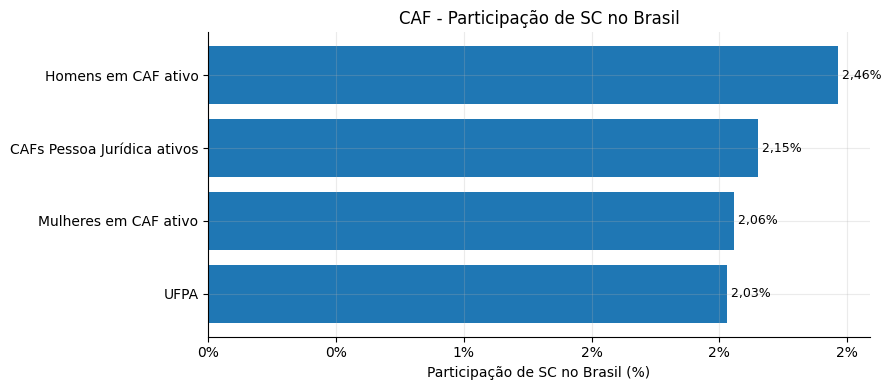

In [76]:
df_caf = df_indicadores_uf[df_indicadores_uf["politica"] == "CAF"].copy()

# Ordem editorial da Tabela CAF: UFPA, Mulheres, Homens, CAF PJ (por \u00faltimo).
ordem_indicadores_caf = [
    "UFPA",
    "Mulheres em CAF ativo",
    "Homens em CAF ativo",
    "CAFs Pessoa Juridica ativos",
]
prioridade_ordem_caf = {indicador: idx for idx, indicador in enumerate(ordem_indicadores_caf)}
df_caf = (
    df_caf.assign(_ordem=df_caf["indicador"].map(prioridade_ordem_caf).fillna(len(ordem_indicadores_caf)))
    .sort_values(["_ordem", "indicador"])
    .drop(columns=["_ordem"])
)
tabela_caf = salvar_tabela_politica(df_caf, "caf_tabela.csv")
grafico_caf = grafico_participacao(df_caf, f"CAF - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "caf_participacao.png")

## 9. PRONAF - tabela e graficos

PRONAF possui dados atuais e serie historica. Por isso, sao gerados graficos de evolucao para valor total dos contratos e quantidade de contratos.

,politica,indicador,SC,Brasil,% SC/Brasil,Ranking Brasil
131,PRONAF,Contratos,18.872,482.017,"3,92%",10º
158,PRONAF,Valor total dos contratos,"R$ 1.706.160.904,82","R$ 14.671.081.816,64","11,63%",2º
212,PRONAF,Contratos com mulheres,1.537,128.756,"1,19%",14º
239,PRONAF,Valor contratos com mulheres,"R$ 157.195.947,67","R$ 2.393.128.376,45","6,57%",5º
266,PRONAF,Contratos com homens,6.680,175.558,"3,81%",10º
293,PRONAF,Valor contratos com homens,"R$ 618.226.327,80","R$ 6.171.962.540,40","10,02%",4º


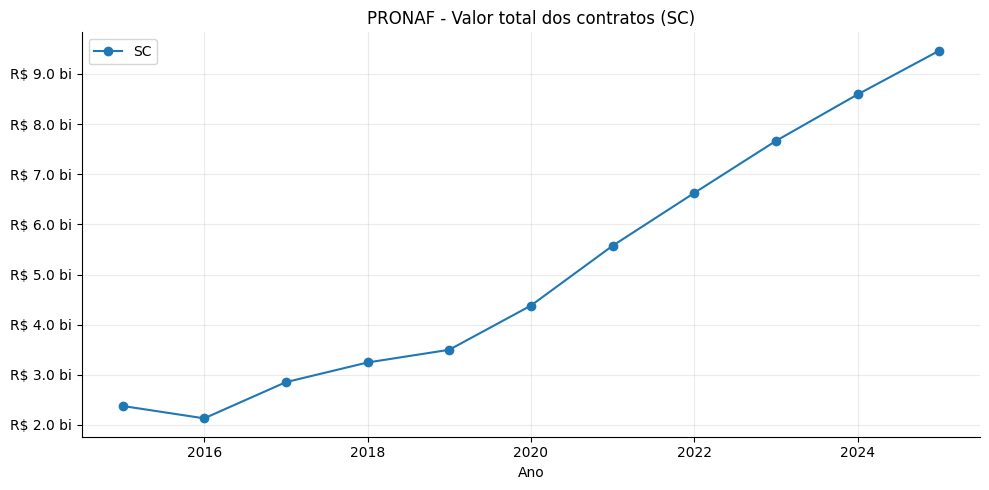

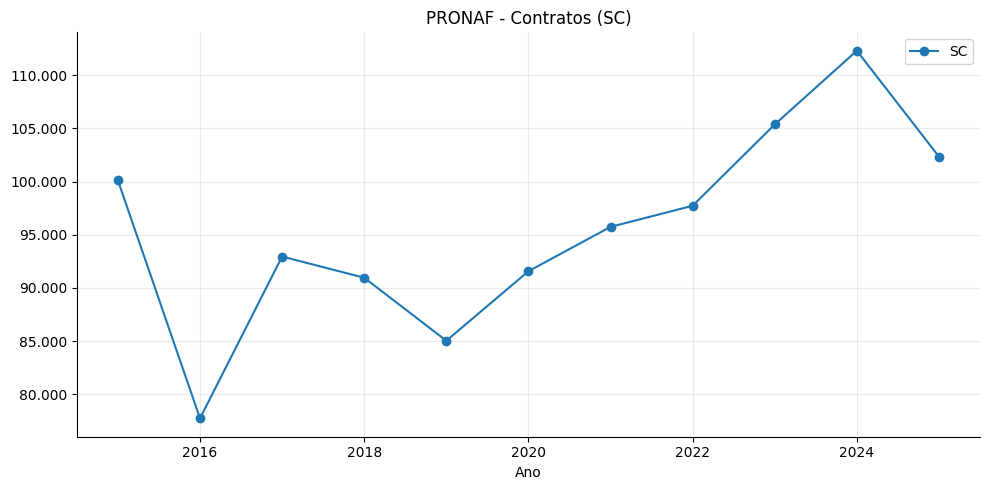

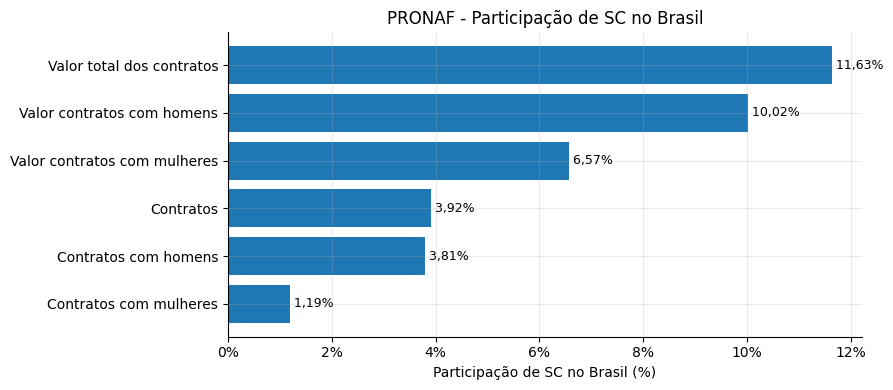

In [77]:
df_pronaf = df_indicadores_uf[df_indicadores_uf["politica"] == "PRONAF"].copy()

# Ajustes editoriais da Tabela PRONAF:
# - Remove duplicidade entre Contratos e Operacoes (mantem Contratos).
# - Padroniza nomenclatura de genero para "com mulheres" e "com homens".
renomear_indicadores_pronaf = {
    "Contratos feminino": "Contratos com mulheres",
    "Contratos femininos": "Contratos com mulheres",
    "Valor contratos feminino": "Valor contratos com mulheres",
    "Valor contratos femininos": "Valor contratos com mulheres",
    "Contratos masculino": "Contratos com homens",
    "Contratos masculinos": "Contratos com homens",
    "Valor contratos masculino": "Valor contratos com homens",
    "Valor contratos masculinos": "Valor contratos com homens",
}
df_pronaf["indicador"] = df_pronaf["indicador"].replace(renomear_indicadores_pronaf)
df_pronaf = df_pronaf[df_pronaf["indicador"] != "Operacoes"].copy()
tabela_pronaf = salvar_tabela_politica(df_pronaf, "pronaf_tabela.csv")
grafico_pronaf_valor = grafico_historico(
    "PRONAF",
    "Valor total dos contratos",
    f"PRONAF - Valor total dos contratos ({UF_INTERESSE})",
    "pronaf_valor_historico.png",
    formato="moeda",
    incluir_brasil=False,
)
grafico_pronaf_contratos = grafico_historico(
    "PRONAF",
    "Contratos",
    f"PRONAF - Contratos ({UF_INTERESSE})",
    "pronaf_contratos_historico.png",
    formato="inteiro",
    incluir_brasil=False,
)
grafico_pronaf_participacao = grafico_participacao(df_pronaf, f"PRONAF - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "pronaf_participacao.png")

## 10. Mais Alimentos - tabela e grafico

A base atual permite comparacao UF/Brasil para contratos e valor contratado.

,politica,indicador,SC,Brasil,% SC/Brasil,Ranking Brasil
320,Mais Alimentos,Contratos,5.527,95.355,"5,80%",7º
347,Mais Alimentos,Valor total dos contratos,"R$ 580.058.120,89","R$ 3.533.334.483,94","16,42%",2º


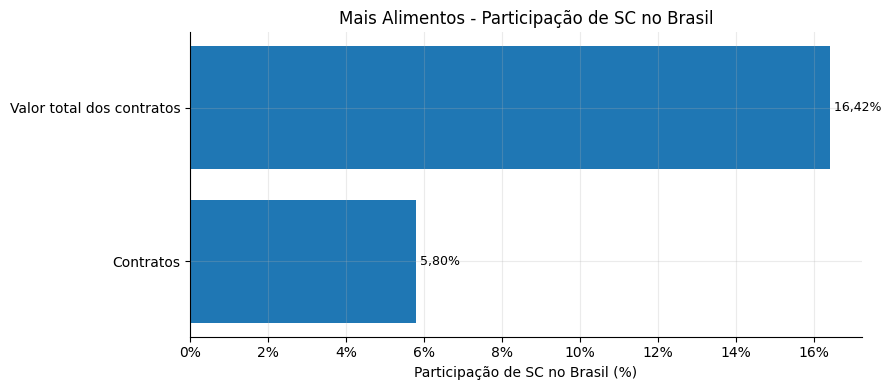

In [78]:
df_mais = df_indicadores_uf[df_indicadores_uf["politica"] == "Mais Alimentos"].copy()
tabela_mais = salvar_tabela_politica(df_mais, "mais_alimentos_tabela.csv")
grafico_mais = grafico_participacao(df_mais, f"Mais Alimentos - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "mais_alimentos_participacao.png")

# Historico anual Mais Alimentos: tabela UF x Brasil e graficos de linha (contratos e valor).
df_mais_anual_uf_uf = df_mais_anual_uf[df_mais_anual_uf["uf"] == UF_INTERESSE].copy() if not df_mais_anual_uf.empty else pd.DataFrame()
df_mais_anual_brasil_ord = df_mais_anual_brasil.sort_values("ano").copy() if not df_mais_anual_brasil.empty else pd.DataFrame()

if not df_mais_anual_uf_uf.empty:
    df_mais_anual_uf_uf = df_mais_anual_uf_uf.sort_values("ano").reset_index(drop=True)

    if not df_mais_anual_brasil_ord.empty:
        base_br_anual = df_mais_anual_brasil_ord.rename(columns={
            "qtd_contratos": "qtd_contratos_brasil",
            "valor_total_contratos": "valor_total_contratos_brasil",
        })[["ano", "qtd_contratos_brasil", "valor_total_contratos_brasil"]]
        merged_mais_anual = df_mais_anual_uf_uf.merge(base_br_anual, on="ano", how="left")
    else:
        merged_mais_anual = df_mais_anual_uf_uf.copy()
        merged_mais_anual["qtd_contratos_brasil"] = 0
        merged_mais_anual["valor_total_contratos_brasil"] = 0

    def _participacao_anual(num, den):
        if den is None or pd.isna(den) or float(den) == 0:
            return None
        return float(num) * 100.0 / float(den)

    linhas_mais_anual = []
    for _, row in merged_mais_anual.iterrows():
        linhas_mais_anual.append({
            "Ano": int(row["ano"]) if pd.notna(row["ano"]) else "",
            f"Contratos ({UF_INTERESSE})": formatar_valor(row["qtd_contratos"], "inteiro"),
            "Contratos (Brasil)": formatar_valor(row["qtd_contratos_brasil"], "inteiro"),
            f"% Contratos {UF_INTERESSE}/Brasil": formatar_percentual(_participacao_anual(row["qtd_contratos"], row["qtd_contratos_brasil"])),
            f"Valor ({UF_INTERESSE})": formatar_valor(row["valor_total_contratos"], "moeda"),
            "Valor (Brasil)": formatar_valor(row["valor_total_contratos_brasil"], "moeda"),
            f"% Valor {UF_INTERESSE}/Brasil": formatar_percentual(_participacao_anual(row["valor_total_contratos"], row["valor_total_contratos_brasil"])),
        })
    tabela_mais_anual = pd.DataFrame(linhas_mais_anual)
    tabela_mais_anual.to_csv(TABELAS_DIR / "mais_alimentos_anual_tabela.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
    display(tabela_mais_anual)

    grafico_mais_contratos_historico = grafico_historico(
        "Mais Alimentos", "Contratos",
        f"Mais Alimentos - Hist\u00f3rico de contratos: {UF_INTERESSE} x Brasil",
        "mais_alimentos_contratos_historico.png",
        formato="inteiro",
        incluir_brasil=True,
    )
    grafico_mais_valor_historico = grafico_historico(
        "Mais Alimentos", "Valor total dos contratos",
        f"Mais Alimentos - Hist\u00f3rico do valor total dos contratos: {UF_INTERESSE} x Brasil",
        "mais_alimentos_valor_historico.png",
        formato="moeda",
        incluir_brasil=True,
    )
else:
    print("Sem historico anual Mais Alimentos disponivel para a UF.")
    tabela_mais_anual = pd.DataFrame()
    grafico_mais_contratos_historico = None
    grafico_mais_valor_historico = None

# Historico mensal Mais Alimentos: tabela UF x Brasil e graficos (acumulado e variacao).
df_mais_hist_uf_uf = df_mais_hist_uf[df_mais_hist_uf["uf"] == UF_INTERESSE].copy() if not df_mais_hist_uf.empty else pd.DataFrame()
df_mais_hist_brasil_ord = df_mais_hist_brasil.sort_values("competencia").copy() if not df_mais_hist_brasil.empty else pd.DataFrame()

if not df_mais_hist_uf_uf.empty:
    df_mais_hist_uf_uf = df_mais_hist_uf_uf.sort_values("competencia").reset_index(drop=True)

    if not df_mais_hist_brasil_ord.empty:
        base_br = df_mais_hist_brasil_ord.rename(columns={
            "qtd_contratos": "qtd_contratos_brasil",
            "valor_total_contratos": "valor_total_contratos_brasil",
        })[["competencia", "qtd_contratos_brasil", "valor_total_contratos_brasil"]]
        merged_mais_hist = df_mais_hist_uf_uf.merge(base_br, on="competencia", how="left")
    else:
        merged_mais_hist = df_mais_hist_uf_uf.copy()
        merged_mais_hist["qtd_contratos_brasil"] = 0
        merged_mais_hist["valor_total_contratos_brasil"] = 0

    def _participacao(num, den):
        if den is None or pd.isna(den) or float(den) == 0:
            return None
        return float(num) * 100.0 / float(den)

    linhas_mais_hist = []
    for _, row in merged_mais_hist.iterrows():
        linhas_mais_hist.append({
            "Compet\u00eancia": row["competencia"],
            f"Contratos acumulados ({UF_INTERESSE})": formatar_valor(row["qtd_contratos"], "inteiro"),
            "Contratos acumulados (Brasil)": formatar_valor(row["qtd_contratos_brasil"], "inteiro"),
            f"% Contratos {UF_INTERESSE}/Brasil": formatar_percentual(_participacao(row["qtd_contratos"], row["qtd_contratos_brasil"])),
            f"Valor acumulado ({UF_INTERESSE})": formatar_valor(row["valor_total_contratos"], "moeda"),
            "Valor acumulado (Brasil)": formatar_valor(row["valor_total_contratos_brasil"], "moeda"),
            f"% Valor {UF_INTERESSE}/Brasil": formatar_percentual(_participacao(row["valor_total_contratos"], row["valor_total_contratos_brasil"])),
        })
    tabela_mais_historico = pd.DataFrame(linhas_mais_hist)
    tabela_mais_historico.to_csv(TABELAS_DIR / "mais_alimentos_historico_tabela.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
    display(tabela_mais_historico)

    grafico_mais_acum_contratos = grafico_historico_mensal(
        df_mais_hist_uf_uf, df_mais_hist_brasil_ord,
        coluna_uf="qtd_contratos", coluna_brasil="qtd_contratos",
        modo="acumulado",
        titulo="Mais Alimentos - Contratos acumulados no ano",
        arquivo_png="mais_alimentos_acumulado_contratos.png",
        formato="inteiro",
    )
    grafico_mais_var_contratos = grafico_historico_mensal(
        df_mais_hist_uf_uf, df_mais_hist_brasil_ord,
        coluna_uf="delta_qtd_contratos", coluna_brasil="delta_qtd_contratos",
        modo="variacao",
        titulo="Mais Alimentos - Varia\u00e7\u00e3o de contratos entre cargas mensais",
        arquivo_png="mais_alimentos_variacao_contratos.png",
        formato="inteiro",
    )
    grafico_mais_acum_valor = grafico_historico_mensal(
        df_mais_hist_uf_uf, df_mais_hist_brasil_ord,
        coluna_uf="valor_total_contratos", coluna_brasil="valor_total_contratos",
        modo="acumulado",
        titulo="Mais Alimentos - Valor total dos contratos acumulado no ano",
        arquivo_png="mais_alimentos_acumulado_valor.png",
        formato="moeda",
    )
    grafico_mais_var_valor = grafico_historico_mensal(
        df_mais_hist_uf_uf, df_mais_hist_brasil_ord,
        coluna_uf="delta_valor_total_contratos", coluna_brasil="delta_valor_total_contratos",
        modo="variacao",
        titulo="Mais Alimentos - Varia\u00e7\u00e3o do valor total entre cargas mensais",
        arquivo_png="mais_alimentos_variacao_valor.png",
        formato="moeda",
    )
else:
    print("Sem historico mensal Mais Alimentos disponivel para a UF.")
    tabela_mais_historico = pd.DataFrame()
    grafico_mais_acum_contratos = None
    grafico_mais_var_contratos = None
    grafico_mais_acum_valor = None
    grafico_mais_var_valor = None

## 11. ATER - tabela e graficos

ATER possui dados atuais e serie historica. Sao gerados graficos para familias com ATER recebida e iniciada.

,politica,indicador,SC,Brasil,% SC/Brasil,Ranking Brasil
374,ATER,Familias com ATER iniciada no ano,563,5.785,"9,73%",3º
401,ATER,Familias com ATER recebida no ano,678,16.855,"4,02%",7º


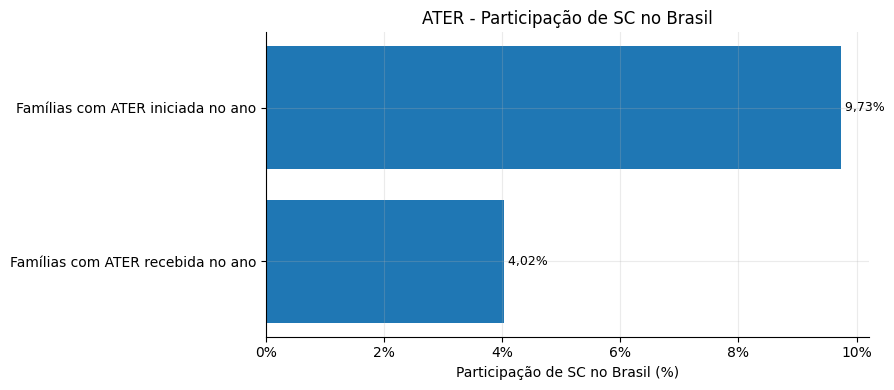

In [79]:
df_ater = df_indicadores_uf[df_indicadores_uf["politica"] == "ATER"].copy()
tabela_ater = salvar_tabela_politica(df_ater, "ater_tabela.csv")

# Graficos historicos de ATER (recebida e iniciada) foram desativados nesta versao do relatorio.
# Motivo: mudanca de metodologia de contagem; dados Anater historicos considerados insuficientes/nao fidedignos.
grafico_ater_recebida = None
grafico_ater_iniciada = None
grafico_ater_participacao = grafico_participacao(df_ater, f"ATER - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "ater_participacao.png")

## 12. Garantia-Safra - tabela e grafico

A base atual permite comparar agricultores aderidos e agricultores com pagamento liberado.

In [80]:
df_gs = df_indicadores_uf[df_indicadores_uf["politica"] == "Garantia-Safra"].copy()
tabela_gs = salvar_tabela_politica(df_gs, "garantia_safra_tabela.csv")
grafico_gs = grafico_participacao(df_gs, f"Garantia-Safra - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "garantia_safra_participacao.png")

,politica,indicador,SC,Brasil,% SC/Brasil,Ranking Brasil
428,Garantia-Safra,Agricultores aderidos,Sem Informação,900.332,Sem Informação,Sem Informação
455,Garantia-Safra,Agricultores com pagamento liberado,Sem Informação,833.621,Sem Informação,Sem Informação


Sem dados numéricos para gerar o gráfico: Garantia-Safra - Participação de SC no Brasil


## 13. PNCF - tabela e grafico

PNCF traz operacoes, valor liberado e valor medio por operacao.

In [81]:
df_pncf = df_indicadores_uf[df_indicadores_uf["politica"] == "PNCF"].copy()
tabela_pncf = salvar_tabela_politica(df_pncf, "pncf_tabela.csv")

# Grafico de participacao do PNCF removido nesta versao do relatorio.
# Motivo: o indicador "Valor medio por operacao" e uma comparacao de medias e nao uma participacao percentual,
# misturando metricas que tornam a leitura enganosa. Aguardando definicao metodologica para reativar.
grafico_pncf = None

,politica,indicador,SC,Brasil,% SC/Brasil,Ranking Brasil
482,PNCF,Operacoes,1,417,"0,24%",16º
509,PNCF,Valor liberado,"R$ 280.000,00","R$ 104.024.293,61","0,27%",16º
536,PNCF,Valor medio liberado por operacao,"R$ 280.000,00","R$ 249.458,74","112,24%",5º


## 14. PNRA - tabela e grafico

PNRA apresenta familias por categoria e total de familias.

,politica,indicador,SC,Brasil,% SC/Brasil,Ranking Brasil
563,PNRA,Famílias em PA Ambientalmente Diferenciado,0,2.341,"0,00%",9º
590,PNRA,Famílias em PA Convencional,0,40,"0,00%",4º
617,PNRA,Famílias Reconhecidas,0,2.000,"0,00%",13º
644,PNRA,Famílias Regularizadas,35,4.738,"0,74%",20º
671,PNRA,Total de familias,35,9.119,"0,38%",22º


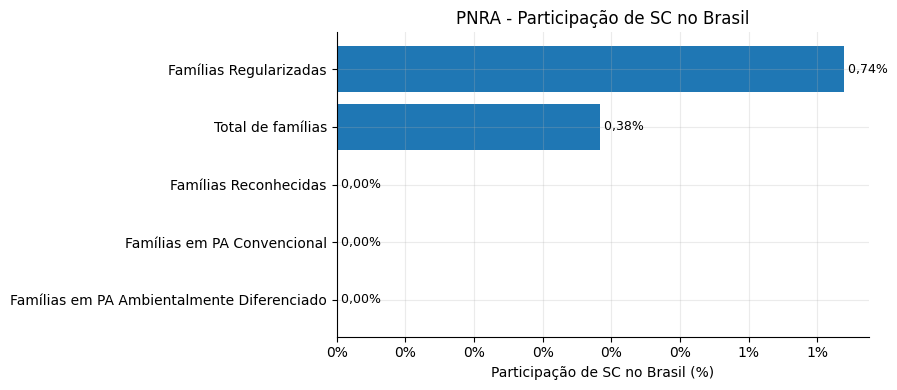

In [82]:
df_pnra = df_indicadores_uf[df_indicadores_uf["politica"] == "PNRA"].copy()

# Ajustes editoriais das categorias do PNRA (Reforma Agraria).
# - Evita o termo "tradicional", que conflita com PCTs.
# - Padroniza nomenclatura de "reconhecimento"/"regularizacao".
renomear_indicadores_pnra = {
    "Familias em PA criado diferenciado": "Fam\u00edlias em PA Ambientalmente Diferenciado",
    "Familias em PA criado tradicional": "Fam\u00edlias em PA Convencional",
    "Familias em reconhecimento": "Fam\u00edlias Reconhecidas",
    "Familias em regulariza\u00e7\u00e3o": "Fam\u00edlias Regularizadas",
    "Familias em regularizacao": "Fam\u00edlias Regularizadas",
}
df_pnra["indicador"] = df_pnra["indicador"].replace(renomear_indicadores_pnra)

tabela_pnra = salvar_tabela_politica(df_pnra, "pnra_tabela.csv")
grafico_pnra = grafico_participacao(df_pnra, f"PNRA - Participa\u00e7\u00e3o de {UF_INTERESSE} no Brasil", "pnra_participacao.png")

## 15. Fontes

A tabela de fontes consolida política, data de referência, data de geração e arquivo de origem. Ela será inserida ao final do Word.

In [83]:
df_fontes = (
    df_indicadores_uf[["politica", "dt_referencia", "dt_geracao", "arquivo_origem"]]
    .drop_duplicates()
    .sort_values(["politica", "arquivo_origem"])
    .reset_index(drop=True)
)
df_fontes.to_csv(TABELAS_DIR / "fontes.csv", sep=CSV_SEP, index=False, encoding=CSV_ENCODING)
display(df_fontes)

,politica,dt_referencia,dt_geracao,arquivo_origem
0,ATER,2026_03,20260410,ater_ate_2026_03_gerado_em_20260410151127.xlsx
1,CAF,2026_03,2026_04_10,caf_dap_ativos_ate_2026_03_gerado_em_202604101...
2,Garantia-Safra,2023-2024,2026_04_13,GARANTIA-SAFRA_2023-2024_ate_2026_04.xlsx
3,Mais Alimentos,2026_03,2026_04_14,mais_alimentos_gaia_202604151554.xlsx
4,PNCF,2026_03,2026_04_10,pncf_2026_03_gerado_em_20260410170006.xlsx
5,PNRA,2026 até mar,2026_04_15,PNRA_2026_2026_04_15.xlsx
6,PRONAF,2026_03,2026_04_14,pronaf_gaia_20260414.xlsx


## 16. Conferir insumos gerados

Antes de montar o Word, o notebook lista tabelas e graficos salvos. Essa conferencia torna a montagem do documento mais previsivel.

In [84]:
tabelas_geradas = sorted(TABELAS_DIR.glob("*.csv"))
graficos_gerados = sorted(GRAFICOS_DIR.glob("*.png"))

df_insumos = pd.DataFrame(
    [{"tipo": "tabela", "arquivo": p.name, "caminho": str(p)} for p in tabelas_geradas]
    + [{"tipo": "grafico", "arquivo": p.name, "caminho": str(p)} for p in graficos_gerados]
)
display(df_insumos)

print(f"Tabelas geradas: {len(tabelas_geradas)}")
print(f"Graficos gerados: {len(graficos_gerados)}")

,tipo,arquivo,caminho
0,tabela,ater_tabela.csv,C:\Users\berna\Documents\mda\automatizacao rel...
1,tabela,caf_tabela.csv,C:\Users\berna\Documents\mda\automatizacao rel...
2,tabela,fontes.csv,C:\Users\berna\Documents\mda\automatizacao rel...
3,tabela,garantia_safra_tabela.csv,C:\Users\berna\Documents\mda\automatizacao rel...
4,tabela,mais_alimentos_tabela.csv,C:\Users\berna\Documents\mda\automatizacao rel...
5,tabela,pncf_tabela.csv,C:\Users\berna\Documents\mda\automatizacao rel...
6,tabela,pnra_tabela.csv,C:\Users\berna\Documents\mda\automatizacao rel...
7,tabela,pronaf_tabela.csv,C:\Users\berna\Documents\mda\automatizacao rel...
8,tabela,sumario_executivo_historico_2019_2022_2023_202...,C:\Users\berna\Documents\mda\automatizacao rel...
9,tabela,sumario_executivo_indicadores_atuais.csv,C:\Users\berna\Documents\mda\automatizacao rel...


Tabelas geradas: 10
Graficos gerados: 10


## 17. Montar documento Word

O Word e montado somente depois que as tabelas e os PNGs ja foram gerados. Isso separa a preparacao dos insumos da etapa editorial.

In [85]:
def adicionar_campo_word(paragrafo, instrucao, texto_padrao="1"):
    """Insere um campo dinamico do Word, como PAGE, em um paragrafo."""
    run_inicio = paragrafo.add_run()
    campo_inicio = OxmlElement("w:fldChar")
    campo_inicio.set(qn("w:fldCharType"), "begin")
    run_inicio._r.append(campo_inicio)

    run_instrucao = paragrafo.add_run()
    instrucao_campo = OxmlElement("w:instrText")
    instrucao_campo.set(qn("xml:space"), "preserve")
    instrucao_campo.text = f" {instrucao} "
    run_instrucao._r.append(instrucao_campo)

    run_separador = paragrafo.add_run()
    campo_separador = OxmlElement("w:fldChar")
    campo_separador.set(qn("w:fldCharType"), "separate")
    run_separador._r.append(campo_separador)

    # O texto padrao aparece ate o Word atualizar o campo; o documento tambem recebe a instrucao para atualizar campos ao abrir.
    run_resultado = paragrafo.add_run(texto_padrao)

    run_fim = paragrafo.add_run()
    campo_fim = OxmlElement("w:fldChar")
    campo_fim.set(qn("w:fldCharType"), "end")
    run_fim._r.append(campo_fim)
    return run_resultado


def extrair_ano_mes_dt_referencia(dt_referencia: str):
    """Extrai (ano, mes) de padrões como 2026_03, 2026-03, 202603, 2026/03.

    Para valores de período (ex.: 2023-2024), retorna o ano mais recente.
    """
    if dt_referencia is None:
        return None, None
    s = str(dt_referencia).strip()
    import re

    m = re.search(r"(20\d{2})\D?(0[1-9]|1[0-2])", s)
    if m:
        return int(m.group(1)), int(m.group(2))
    m = re.search(r"(20\d{2})(0[1-9]|1[0-2])", s)
    if m:
        return int(m.group(1)), int(m.group(2))

    # Ex.: "2023-2024" -> usa 2024 para evitar exibição desatualizada do período Safra.
    anos = [int(a) for a in re.findall(r"20\d{2}", s)]
    if anos:
        return max(anos), None

    return None, None


def ano_referencia_politica(df_indicadores_uf, politica: str | None):
    """Retorna o ano de referência a partir de dt_referencia.

    - Se `politica` for informada, usa as linhas dessa política.
    - Se `politica` for None, usa o conjunto todo (útil para título geral e tabelas agregadas).
    """
    if df_indicadores_uf is None or df_indicadores_uf.empty:
        return None
    if politica is None:
        dfp = df_indicadores_uf
    else:
        dfp = (
            df_indicadores_uf[df_indicadores_uf["politica"] == politica].copy()
            if "politica" in df_indicadores_uf.columns
            else df_indicadores_uf
        )
    if "dt_referencia" in dfp.columns and not dfp["dt_referencia"].dropna().empty:
        anos = []
        for v in dfp["dt_referencia"].dropna().astype(str).unique():
            ano, _ = extrair_ano_mes_dt_referencia(v)
            if ano:
                anos.append(ano)
        if anos:
            return max(anos)
    if "dt_referencia" in df_indicadores_uf.columns and not df_indicadores_uf["dt_referencia"].dropna().empty:
        anos = []
        for v in df_indicadores_uf["dt_referencia"].dropna().astype(str).unique():
            ano, _ = extrair_ano_mes_dt_referencia(v)
            if ano:
                anos.append(ano)
        if anos:
            return max(anos)
    return None


def sufixo_ano(ano: int | None) -> str:
    return f" - {ano}" if ano else ""


# Nome de exibição (editorial) sem alterar filtros/dados.
POLITICA_DISPLAY = {
    "ATER": "ATER (Anater)",
}


doc = Document()
normal_style = doc.styles["Normal"]
normal_style.font.name = "Arial"
normal_style.font.size = Pt(10)

# Solicita ao Word atualizar campos dinamicos, como PAGE, ao abrir o arquivo.
atualizar_campos = OxmlElement("w:updateFields")
atualizar_campos.set(qn("w:val"), "true")
doc.settings.element.append(atualizar_campos)

# Aplica a imagem institucional no cabecalho, alinhada a direita.
# A imagem fica em templates/imagens/institucional para permitir troca futura sem alterar a logica do relatorio.
for secao in doc.sections:
    secao.header_distance = Inches(0.15)
    paragrafo_cabecalho = secao.header.paragraphs[0]
    paragrafo_cabecalho.text = ""
    paragrafo_cabecalho.alignment = WD_ALIGN_PARAGRAPH.RIGHT
    run_cabecalho = paragrafo_cabecalho.add_run()
    run_cabecalho.add_picture(str(CAMINHO_IMAGEM_CABECALHO), width=Inches(LARGURA_IMAGEM_CABECALHO_POLEGADAS))

# Aplica o rodape institucional em todas as secoes do documento.
# A primeira linha traz o contato; a segunda linha traz a paginacao no padrao "Pagina X de Y".
for secao in doc.sections:
    paragrafo_rodape = secao.footer.paragraphs[0]
    paragrafo_rodape.text = TEXTO_RODAPE
    paragrafo_rodape.alignment = WD_ALIGN_PARAGRAPH.CENTER
    for run in paragrafo_rodape.runs:
        run.font.name = "Arial"
        run.font.size = Pt(9)

    paragrafo_paginacao = secao.footer.add_paragraph()
    paragrafo_paginacao.alignment = WD_ALIGN_PARAGRAPH.CENTER
    paragrafo_paginacao.add_run("Página ")
    adicionar_campo_word(paragrafo_paginacao, "PAGE")
    paragrafo_paginacao.add_run(f" de {PLACEHOLDER_TOTAL_PAGINAS}")
    for run in paragrafo_paginacao.runs:
        run.font.name = "Arial"
        run.font.size = Pt(9)

ano_relatorio = ano_referencia_politica(df_indicadores_uf, politica=None) if "df_indicadores_uf" in globals() else None

titulo = doc.add_heading(
    f"Relat\u00f3rio Estadual de Dados - {nome_uf} ({UF_INTERESSE}){sufixo_ano(ano_relatorio)}",
    level=0,
)
titulo.alignment = WD_ALIGN_PARAGRAPH.CENTER
doc.add_paragraph(f"Gerado em: {RUN_TIMESTAMP:%d/%m/%Y %H:%M}")

doc.add_heading("Sum\u00e1rio Executivo", level=1)
doc.add_paragraph(
    f"A tabela a seguir apresenta indicadores selecionados para {nome_uf}, "
    "comparando os resultados do estado com o total nacional e indicando sua posi\u00e7\u00e3o "
    "no ranking das Unidades da Federa\u00e7\u00e3o no m\u00eas de refer\u00eancia."
)

numero_tabela = 1
ano_tabela_1 = ano_referencia_politica(df_indicadores_uf, politica=None)

adicionar_tabela_formatada_word(
    doc,
    preparar_tabela_sumario_executivo_word(df_sumario_executivo),
    f"Tabela {numero_tabela} \u2014 Indicadores selecionados de {nome_uf} em pol\u00edticas do MDA{sufixo_ano(ano_tabela_1)}",
)
numero_tabela += 1

doc.add_paragraph("A tabela seguinte apresenta a soma dos dados hist\u00f3ricos dispon\u00edveis em dois per\u00edodos: 2019 a 2022 e 2023 a 2026 (incompleto).")
tabela_hist_word = df_sumario_historico.copy()
if not tabela_hist_word.empty:
    coluna_uf_2019_2022 = f"{UF_INTERESSE} 2019-2022"
    coluna_uf_2023_2026 = f"{UF_INTERESSE} 2023-2026"
    coluna_variacao_uf = f"Var. {UF_INTERESSE}"
    tabela_hist_word[coluna_uf_2019_2022] = tabela_hist_word.apply(lambda row: formatar_valor(row["valor_uf_2019_2022"], row["formato"]), axis=1)
    tabela_hist_word[coluna_uf_2023_2026] = tabela_hist_word.apply(lambda row: formatar_valor(row["valor_uf_2023_2026"], row["formato"]), axis=1)
    tabela_hist_word[coluna_variacao_uf] = tabela_hist_word["variacao_uf_pct"].apply(formatar_percentual)
    tabela_hist_word["Brasil 2019-2022"] = tabela_hist_word.apply(lambda row: formatar_valor(row["valor_brasil_2019_2022"], row["formato"]), axis=1)
    tabela_hist_word["Brasil 2023-2026"] = tabela_hist_word.apply(lambda row: formatar_valor(row["valor_brasil_2023_2026"], row["formato"]), axis=1)
    tabela_hist_word["Var. Brasil"] = tabela_hist_word["variacao_brasil_pct"].apply(formatar_percentual)
    tabela_hist_word = tabela_hist_word[["politica", "indicador", coluna_uf_2019_2022, coluna_uf_2023_2026, coluna_variacao_uf, "Brasil 2019-2022", "Brasil 2023-2026", "Var. Brasil"]]
adicionar_tabela_formatada_word(
    doc,
    tabela_hist_word,
    f"Tabela {numero_tabela} \u2014 S\u00edntese hist\u00f3rica de indicadores selecionados de {nome_uf}",
    nota="Nota: per\u00edodo 2023 a 2026 incompleto; a tabela soma apenas os anos dispon\u00edveis nos dados administrativos. Valores financeiros em reais correntes.",
)
numero_tabela += 1

secoes = [
    ("CAF - Cadastro da Agricultura Familiar", tabela_caf, [grafico_caf], "Indicadores do CAF", "CAF", []),
    ("PRONAF", tabela_pronaf, [grafico_pronaf_valor, grafico_pronaf_contratos, grafico_pronaf_participacao], "Indicadores do PRONAF", "PRONAF", []),
    (
        "Mais Alimentos",
        tabela_mais,
        [grafico_mais, grafico_mais_contratos_historico, grafico_mais_valor_historico, grafico_mais_acum_contratos, grafico_mais_var_contratos, grafico_mais_acum_valor, grafico_mais_var_valor],
        "Indicadores do Mais Alimentos",
        "Mais Alimentos",
        [
            (tabela_mais_anual, f"Hist\u00f3rico anual do Mais Alimentos em {nome_uf} (2013-2025)"),
            (tabela_mais_historico, f"Mais Alimentos em {nome_uf} - acumulado mensal no ano corrente"),
        ],
    ),
    # ATER: graficos historicos desativados; mantem apenas participacao quando disponivel.
    ("ATER", tabela_ater, [grafico_ater_participacao], "Indicadores de ATER", "ATER", []),
    ("Garantia-Safra", tabela_gs, [grafico_gs], "Indicadores do Garantia-Safra", "Garantia-Safra", []),
    # PNCF: grafico de participacao desativado aguardando definicao metodologica.
    ("PNCF", tabela_pncf, [], "Indicadores do PNCF", "PNCF", []),
    ("PNRA - Reforma Agr\u00e1ria", tabela_pnra, [grafico_pnra], "Indicadores do PNRA", "PNRA", []),
]

numero_grafico = 1
for titulo_secao, tabela_secao, graficos_secao, titulo_tabela_secao, politica_chave, tabelas_extras in secoes:
    ano_secao = ano_referencia_politica(df_indicadores_uf, politica_chave)

    titulo_exibicao = POLITICA_DISPLAY.get(titulo_secao, titulo_secao)
    titulo_tabela_exibicao = titulo_tabela_secao
    if politica_chave in POLITICA_DISPLAY:
        # Ajusta apenas exibição editorial.
        titulo_tabela_exibicao = titulo_tabela_exibicao.replace(politica_chave, POLITICA_DISPLAY[politica_chave])

    doc.add_heading(titulo_exibicao, level=1)
    adicionar_tabela_formatada_word(
        doc,
        tabela_secao,
        f"Tabela {numero_tabela} — {titulo_tabela_exibicao} em {nome_uf}{sufixo_ano(ano_secao)}",
    )
    numero_tabela += 1
    for tabela_extra, titulo_extra in tabelas_extras:
        if tabela_extra is None:
            continue
        if isinstance(tabela_extra, pd.DataFrame) and tabela_extra.empty:
            continue
        adicionar_tabela_formatada_word(
            doc,
            tabela_extra,
            f"Tabela {numero_tabela} \u2014 {titulo_extra}{sufixo_ano(ano_secao)}",
        )
        numero_tabela += 1
    for grafico in graficos_secao:
        if grafico is not None and Path(grafico).exists():
            paragrafo_titulo_grafico = adicionar_texto_apoio_tabela(
                doc,
                titulo_grafico_word(grafico, numero_grafico),
                negrito=True,
                tamanho=9,
                espaco_depois=2,
            )
            # Mantém o título do gráfico junto da imagem quando houver quebra de página.
            paragrafo_titulo_grafico.paragraph_format.keep_with_next = True
            doc.add_picture(str(grafico), width=Inches(6.2))
            numero_grafico += 1

doc.add_heading("Fontes", level=1)
adicionar_tabela_formatada_word(
    doc,
    df_fontes,
    f"Tabela {numero_tabela} \u2014 Fontes administrativas utilizadas no relat\u00f3rio de {nome_uf}",
    fonte="Fonte: elabora\u00e7\u00e3o pr\u00f3pria, com base no invent\u00e1rio de arquivos de entrada e bases consolidadas.",
    nota="Nota: cada linha identifica a pol\u00edtica, o m\u00eas de refer\u00eancia, a data de gera\u00e7\u00e3o e o arquivo de origem utilizado no relat\u00f3rio.",
)

nome_docx = f"relatorio_dados_{UF_INTERESSE}_{RUN_DATETIME}.docx"
caminho_docx = OUTPUT_DIR / nome_docx
doc.save(caminho_docx)

# Em execução local no Windows, calcula o total de páginas pelo Microsoft Word e substitui o marcador do rodape.
# O numero da pagina atual permanece como campo PAGE, e o total de páginas fica congelado conforme o documento gerado.
if MODO_DADOS == "local" and os.name == "nt":
    try:
        import win32com.client

        word_app = win32com.client.DispatchEx("Word.Application")
        word_app.Visible = False
        word_app.DisplayAlerts = 0
        doc_word = word_app.Documents.Open(str(caminho_docx.resolve()))
        doc_word.Repaginate()
        total_paginas = int(doc_word.ComputeStatistics(2))
        doc_word.Fields.Update()
        for secao_word in doc_word.Sections:
            for indice_rodape in [1, 2, 3]:
                try:
                    faixa_rodape = secao_word.Footers(indice_rodape).Range
                    faixa_rodape.Fields.Update()
                    faixa_rodape.Find.Execute(FindText=PLACEHOLDER_TOTAL_PAGINAS, ReplaceWith=str(total_paginas), Replace=2)
                except Exception:
                    pass
        doc_word.Repaginate()
        doc_word.Save()
        doc_word.Close(False)
        word_app.Quit()
        print(f"Rodap\u00e9 atualizado com total de p\u00e1ginas calculado pelo Word: {total_paginas}")
    except Exception as erro:
        print(f"Nao foi possivel atualizar os campos pelo Microsoft Word: {erro}")

print(f"Relat\u00f3rio Word gerado: {caminho_docx}")

Nao foi possivel atualizar os campos pelo Microsoft Word: No module named 'win32com'
Relatório Word gerado: C:\Users\berna\Documents\mda\automatizacao relatorio\relatorios_gerados\202605\relatorio_dados_SC_20260514110436.docx
